In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt
from importlib import reload
from datetime import date, datetime 

# Add utils to path
sys.path.insert(0, os.path.abspath('../utils'))

print("✅ Base imports done")

d:\Desktop\ENGG\E3_Mini_Project\Building_Energy_Consumption_Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Base imports done


In [2]:
with open('../models/xgb_time_model.pkl', 'rb') as f:
    model = pickle.load(f)

explainer = shap.TreeExplainer(model)

print("✅ Model loaded")
print("✅ SHAP explainer ready")

✅ Model loaded
✅ SHAP explainer ready


In [3]:
import feature_labels as fl
reload(fl)
from feature_labels import (
    get_feature_label,
    get_value_label,
    PRIMARY_USE_LABELS,
    METER_LABELS,
    SITE_LABELS,
    MONTH_LABELS
)

print("✅ Feature labels loaded")
print("Building types available:")
for k, v in PRIMARY_USE_LABELS.items():
    print(f"  {k} -> {v}")

✅ Feature labels loaded
Building types available:
  0 -> Education
  1 -> Entertainment/Public Assembly
  2 -> Food Sales and Service
  3 -> Healthcare
  4 -> Lodging/Residential
  5 -> Manufacturing/Industrial
  6 -> Office
  7 -> Other
  8 -> Parking
  9 -> Public Services
  10 -> Religious Worship
  11 -> Retail
  12 -> Services
  13 -> Technology/Science
  14 -> Utility
  15 -> Warehouse/Storage


In [4]:
import recommendations as rec_module
reload(rec_module)
from recommendations import (
    generate_recommendations,
    format_recommendations
)

print("✅ Recommendations module loaded")

✅ Recommendations module loaded


In [5]:
import summary as sum_module
reload(sum_module)
from summary import (
    generate_summary,
    generate_full_report
)

print("✅ Summary module loaded")

✅ Summary module loaded


In [6]:
# Test building — change values here to test different scenarios
new_building = pd.DataFrame({
    "meter":              [1],      # Chilled Water
    "site_id":            [5],
    "primary_use":        [2],      # Food Sales and Service
    "square_feet":        [120000],
    "air_temperature":    [30],
    "cloud_coverage":     [4],
    "dew_temperature":    [22],
    "precip_depth_1_hr":  [0],
    "sea_level_pressure": [1015],
    "wind_direction":     [200],
    "wind_speed":         [3],
    "hour":               [14],
    "month":              [7],
    "weekday":            [3],
    "is_weekend":         [0]
})

print("✅ Test building created")
print(new_building)

✅ Test building created
   meter  site_id  primary_use  square_feet  air_temperature  cloud_coverage  \
0      1        5            2       120000               30               4   

   dew_temperature  precip_depth_1_hr  sea_level_pressure  wind_direction  \
0               22                  0                1015             200   

   wind_speed  hour  month  weekday  is_weekend  
0           3    14      7        3           0  


In [7]:
pred_log = model.predict(new_building)[0]
pred_kwh = np.expm1(pred_log)

print(f"Predicted log value : {pred_log:.4f}")
print(f"Predicted kWh       : {pred_kwh:,.2f} kWh")

Predicted log value : 6.1794
Predicted kWh       : 481.70 kWh


In [8]:
print("=== Feature Name Mapping ===")
for col in new_building.columns:
    print(f"  {col:25} -> {get_feature_label(col)}")

print("\n=== Value Decoding ===")
for col in new_building.columns:
    val = new_building[col].iloc[0]
    print(f"  {col:25} = {str(val):10} -> {get_value_label(col, val)}")

=== Feature Name Mapping ===
  meter                     -> Energy Meter Type
  site_id                   -> Site Location
  primary_use               -> Building Type
  square_feet               -> Building Area (sq ft)
  air_temperature           -> Outdoor Temperature (C)
  cloud_coverage            -> Cloud Coverage
  dew_temperature           -> Dew Point Temperature (C)
  precip_depth_1_hr         -> Rainfall (mm/hr)
  sea_level_pressure        -> Sea Level Pressure (hPa)
  wind_direction            -> Wind Direction
  wind_speed                -> Wind Speed (m/s)
  hour                      -> Hour of Day
  month                     -> Month
  weekday                   -> Day of Week
  is_weekend                -> Weekend Indicator

=== Value Decoding ===
  meter                     = 1          -> Chilled Water
  site_id                   = 5          -> Site 5
  primary_use               = 2          -> Food Sales and Service
  square_feet               = 120000     -> 120,000

In [9]:
shap_values   = explainer.shap_values(new_building)[0]
feature_names  = new_building.columns.tolist()
feature_values = new_building.iloc[0].tolist()

# Sort by absolute impact
shap_pairs = sorted(
    zip(feature_names, shap_values),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("=== SHAP Values (sorted by impact) ===")
for fname, fval in shap_pairs:
    direction = "+" if fval > 0 else "-"
    label = get_feature_label(fname)
    print(f"  {label:35} {direction}{abs(fval):.4f}")

=== SHAP Values (sorted by impact) ===
  Energy Meter Type                   +0.4945
  Building Area (sq ft)               +0.3892
  Building Type                       +0.3518
  Outdoor Temperature (C)             +0.2778
  Hour of Day                         +0.2680
  Site Location                       -0.2538
  Month                               +0.2099
  Dew Point Temperature (C)           +0.2050
  Day of Week                         +0.0750
  Sea Level Pressure (hPa)            +0.0361
  Weekend Indicator                   +0.0100
  Wind Direction                      -0.0088
  Wind Speed (m/s)                    -0.0021
  Cloud Coverage                      -0.0016
  Rainfall (mm/hr)                    -0.0009


In [10]:
recs = generate_recommendations(
    shap_values,
    feature_names,
    feature_values
)

print(format_recommendations(recs))

ENERGY SAVING RECOMMENDATIONS

1. Energy Meter Type: Chilled Water
   Impact: +0.50 on log scale
   Action: Your meter type indicates high energy demand. Review equipment schedules and consider switching to more energy efficient systems where possible.
   Estimated Saving: 5-10%

2. Building Area (sq ft): 120,000
   Impact: +0.39 on log scale
   Action: Your building size is a major energy driver. Consider implementing HVAC zoning to heat/cool only occupied areas instead of the entire building.
   Estimated Saving: 8-15%

3. Building Type: Food Sales and Service
   Impact: +0.35 on log scale
   Action: Buildings of this type typically benefit from occupancy-based controls. Install smart sensors to automatically reduce energy use in empty spaces.
   Estimated Saving: 7-13%

Total Potential Saving: 20-38%


In [11]:
summary_text = generate_summary(
    prediction_kwh     = pred_kwh,
    building_type_code = new_building['primary_use'].iloc[0],
    area               = new_building['square_feet'].iloc[0],
    site_id            = new_building['site_id'].iloc[0],
    meter_code         = new_building['meter'].iloc[0],
    recommendations    = recs,
    period             = "monthly",
    month              = 7,
    year               = 2025
)

print("=== SUMMARY ===\n")
print(summary_text)

=== SUMMARY ===

This Food Sales and Service building (120,000 sq ft) at Site 5 is predicted to consume 481.7 kWh in July 2025 using the Chilled Water meter. Based on SHAP analysis, the building is currently highly inefficient 🔴, with the primary energy drivers being Energy Meter Type, Building Area (sq ft) and Building Type. By implementing the 3 recommended actions, an estimated 20-38% reduction in energy consumption is achievable, potentially saving between 96 and 183 kWh in July 2025. Immediate action is recommended to bring this building's energy consumption within acceptable efficiency ranges.


In [12]:
report = generate_full_report(
    prediction_kwh     = pred_kwh,
    building_type_code = new_building['primary_use'].iloc[0],
    area               = new_building['square_feet'].iloc[0],
    site_id            = new_building['site_id'].iloc[0],
    meter_code         = new_building['meter'].iloc[0],
    recommendations    = recs,
    period             = "monthly",
    month              = 7,
    year               = 2025
)

print("=== FULL REPORT ===\n")
for key, val in report.items():
    if key != "recommendations":
        print(f"  {key:20} -> {val}")

print("\n=== RECOMMENDATIONS IN REPORT ===")
for i, r in enumerate(report['recommendations'], 1):
    print(f"  {i}. {r['feature_label']}: {r['feature_value']}")
    print(f"     Saving: {r['saving_min']}-{r['saving_max']}%")

=== FULL REPORT ===

  summary_text         -> This Food Sales and Service building (120,000 sq ft) at Site 5 is predicted to consume 481.7 kWh in July 2025 using the Chilled Water meter. Based on SHAP analysis, the building is currently highly inefficient 🔴, with the primary energy drivers being Energy Meter Type, Building Area (sq ft) and Building Type. By implementing the 3 recommended actions, an estimated 20-38% reduction in energy consumption is achievable, potentially saving between 96 and 183 kWh in July 2025. Immediate action is recommended to bring this building's energy consumption within acceptable efficiency ranges.
  prediction_kwh       -> 481.69671630859375
  building_type        -> Food Sales and Service
  meter_type           -> Chilled Water
  area                 -> 120000
  site                 -> Site 5
  total_saving_min     -> 20
  total_saving_max     -> 38
  period               -> monthly
  month                -> July
  year                 -> 2025

=== RECO

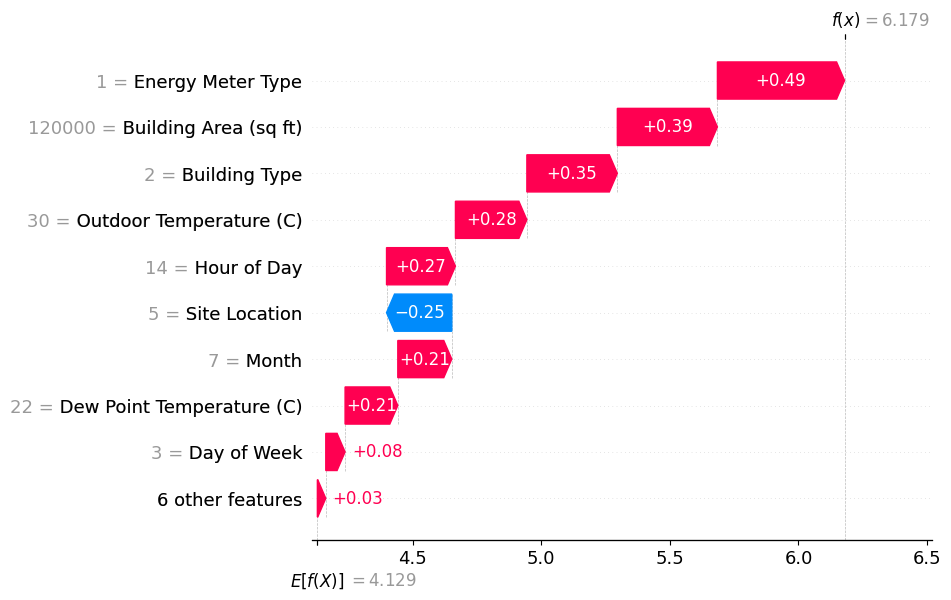

In [13]:
shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values,
        base_values   = explainer.expected_value,
        data          = new_building.iloc[0],
        feature_names = [get_feature_label(f) for f in feature_names]
    )
)

In [14]:
import sys
import os
sys.path.insert(0, os.path.abspath('../utils'))

import feature_generator as fg
reload(fg)
from feature_generator import get_coordinates, get_weather

# Test city lookup
result = get_coordinates("Hyderabad")
if result:
    lat, lon, name = result
    print(f"City found: {name}")
    print(f"Lat: {lat}, Lon: {lon}")
else:
    print("City not found")

City found: Hyderabad, Bahadurpura mandal, Hyderabad, Telangana, India
Lat: 17.360589, Lon: 78.4740613


In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('../utils'))

import feature_generator as fg
reload(fg)
from feature_generator import get_coordinates, get_weather

# Test city lookup
result = get_coordinates("Hyderabad")
if result:
    lat, lon, name = result
    print(f"City found: {name}")
    print(f"Lat: {lat}, Lon: {lon}")
else:
    print("City not found")

City found: Hyderabad, Bahadurpura mandal, Hyderabad, Telangana, India
Lat: 17.360589, Lon: 78.4740613


In [17]:
from datetime import date
from feature_generator import generate_single_features

input_df = generate_single_features(
    building_type = "Office",
    area          = 50000,
    city_name     = "Hyderabad",
    target_date   = date(2025, 6, 15),
    hour          = 14,
    meter_type    = "Electricity"
)

print("=== Generated Features ===")
print(input_df.T)

=== Generated Features ===
                          0
meter                   0.0
site_id                 8.0
primary_use             6.0
square_feet         50000.0
air_temperature        28.0
cloud_coverage          7.0
dew_temperature        25.0
precip_depth_1_hr       5.0
sea_level_pressure   1005.0
wind_direction        200.0
wind_speed             18.0
hour                   14.0
month                   6.0
weekday                 6.0
is_weekend              1.0


In [18]:
from feature_generator import generate_single_features

input_df = generate_single_features(
    building_type = "Office",
    area          = 50000,
    city_name     = "Hyderabad",
    target_date   = date(2025, 6, 15),
    hour          = 14,
    meter_type    = "Electricity"
)

print("=== Generated Features ===")
print(input_df.T)

=== Generated Features ===
                          0
meter                   0.0
site_id                 8.0
primary_use             6.0
square_feet         50000.0
air_temperature        28.0
cloud_coverage          7.0
dew_temperature        25.0
precip_depth_1_hr       5.0
sea_level_pressure   1005.0
wind_direction        200.0
wind_speed             18.0
hour                   14.0
month                   6.0
weekday                 6.0
is_weekend              1.0


In [19]:
from feature_generator import predict_monthly

result = predict_monthly(
    building_type = "Office",
    area          = 50000,
    city_name     = "Hyderabad",
    year          = 2025,
    month         = 6,
    meter_type    = "Electricity",
    model         = model
)

print(f"Monthly Total : {result['monthly_total_kwh']:,.0f} kWh")
print(f"Peak Day      : Day {int(result['peak_day']['day'])}")
print(f"Peak Day kWh  : {result['peak_day']['total_kwh']:,.0f} kWh")
print(f"\nDaily Breakdown:")
print(result['daily_breakdown'])

Monthly Total : 45,240 kWh
Peak Day      : Day 6
Peak Day kWh  : 1,689 kWh

Daily Breakdown:
    day    total_kwh
0     1  1340.255127
1     2  1158.519043
2     3  1687.320312
3     4  1687.320312
4     5  1682.121094
5     6  1689.190063
6     7  1440.555908
7     8  1340.255127
8     9  1158.519043
9    10  1687.320312
10   11  1687.320312
11   12  1682.121094
12   13  1689.190063
13   14  1440.555908
14   15  1340.255127
15   16  1158.519043
16   17  1687.320312
17   18  1687.320312
18   19  1682.121094
19   20  1689.190063
20   21  1440.555908
21   22  1340.255127
22   23  1158.519043
23   24  1687.320312
24   25  1687.320312
25   26  1682.121094
26   27  1689.190063
27   28  1440.555908
28   29  1340.255127
29   30  1158.519043


In [20]:
from datetime import date
from feature_generator import generate_single_features

input_df = generate_single_features(
    building_type = "Office",
    area          = 50000,
    city_name     = "Hyderabad",
    target_date   = date(2024, 6, 15),  # ← past date
    hour          = 14,
    meter_type    = "Electricity"
)

print("=== Generated Features ===")
print(input_df.T)

=== Generated Features ===
                          0
meter                   0.0
site_id                 8.0
primary_use             6.0
square_feet         50000.0
air_temperature        28.0
cloud_coverage          7.0
dew_temperature        25.0
precip_depth_1_hr       5.0
sea_level_pressure   1005.0
wind_direction        200.0
wind_speed             18.0
hour                   14.0
month                   6.0
weekday                 5.0
is_weekend              1.0


In [21]:
import requests

# Test if Open-Meteo API is reachable
lat, lon = 17.3850, 78.4867  # Hyderabad

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude":   lat,
    "longitude":  lon,
    "hourly":     ["temperature_2m", "dewpoint_2m",
                   "precipitation", "cloudcover",
                   "surface_pressure", "windspeed_10m",
                   "winddirection_10m"],
    "start_date": "2024-06-15",
    "end_date":   "2024-06-15",
    "timezone":   "auto"
}

try:
    response = requests.get(url, params=params, timeout=10)
    print("Status code:", response.status_code)
    print("Response:", response.json())
except Exception as e:
    print("Error:", e)

Status code: 400
Response: {'reason': "Parameter 'start_date' is out of allowed range from 2025-12-08 to 2026-03-26", 'error': True}


In [22]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude":   17.3850,
    "longitude":  78.4867,
    "start_date": "2024-06-01",
    "end_date":   "2024-06-30",
    "hourly":     [
        "temperature_2m",
        "dewpoint_2m",
        "precipitation",
        "cloudcover",
        "surface_pressure",
        "windspeed_10m",
        "winddirection_10m"
    ],
    "timezone": "auto"
}

response = requests.get(url, params=params, timeout=10)
data = response.json()

print("Status:", response.status_code)

if "hourly" in data:
    print("✅ Archive API working!")
    print("Temperature sample:", 
          data["hourly"]["temperature_2m"][:5])
else:
    print("❌ Error:", data)

Status: 200
✅ Archive API working!
Temperature sample: [29.1, 29.4, 29.6, 28.4, 27.6]


In [23]:
import feature_generator as fg
reload(fg)
from feature_generator import get_monthly_weather_averages

weather = get_monthly_weather_averages(
    lat=17.3850, lon=78.4867,
    year=2025, month=6
)

print("=== Monthly Weather Averages (Hyderabad, June) ===")
for k, v in weather.items():
    print(f"  {k:25} -> {v:.2f}")

=== Monthly Weather Averages (Hyderabad, June) ===
  air_temperature           -> 27.06
  dew_temperature           -> 21.85
  precip_depth_1_hr         -> 0.41
  cloud_coverage            -> 9.38
  sea_level_pressure        -> 949.28
  wind_speed                -> 12.86
  wind_direction            -> 252.97


In [24]:
from feature_generator import predict_monthly

result = predict_monthly(
    building_type = "Office",
    area          = 50000,
    city_name     = "Hyderabad",
    year          = 2025,
    month         = 6,
    meter_type    = "Electricity",
    model         = model
)

print(f"Monthly Total : {result['monthly_total_kwh']:,.0f} kWh")
print(f"Peak Day      : Day {int(result['peak_day']['day'])}")
print(f"Peak kWh      : {result['peak_day']['total_kwh']:,.0f} kWh")

Monthly Total : 43,167 kWh
Peak Day      : Day 6
Peak kWh      : 1,514 kWh


In [25]:
result_hyd = predict_monthly(
    building_type="Office", area=50000,
    city_name="Hyderabad", year=2025,
    month=6, meter_type="Electricity", model=model
)

result_tokyo = predict_monthly(
    building_type="Office", area=50000,
    city_name="Tokyo", year=2025,
    month=6, meter_type="Electricity", model=model
)

result_london = predict_monthly(
    building_type="Office", area=50000,
    city_name="London", year=2025,
    month=6, meter_type="Electricity", model=model
)

print(f"Hyderabad June : {result_hyd['monthly_total_kwh']:,.0f} kWh")
print(f"Tokyo June     : {result_tokyo['monthly_total_kwh']:,.0f} kWh")
print(f"London June    : {result_london['monthly_total_kwh']:,.0f} kWh")

Hyderabad June : 43,167 kWh
Tokyo June     : 38,922 kWh
London June    : 43,228 kWh
